# Metadatos
## Índice
1. [Obtención de Metadatos y Eliminación de Respuesta](#1-obtención-eliminación)

2. [Lectura y Visualización de Metadatos de Estaciones](#2-visualizar-estaciones)

3. [Lectura y Visualización de Metadatos de Eventos Sísmicos](#3-visualizar-eventos)

4. [Creación de un Catálogo de Eventos Personalizado](#4-catálogo)

## 1. Obtención de Metadatos y Eliminación de Respuesta <a id="1-obtención-eliminación"></a>
Esta sección se basa en la primera libreta que compartiste. 

Exploramos cómo obtener metadatos de estaciones sísmicas y cómo eliminar la respuesta instrumental de los datos sísmicos utilizando ObsPy.

In [2]:
import obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

In [3]:
# Conexión al cliente IRIS
client = Client("IRIS")

# Solicitud de metadatos de estaciones
t1 = obspy.UTCDateTime("2020-07-01")
inv = client.get_stations(network="IW", station="PLID", channel="BHZ", level="response", starttime=t1)
inv += client.get_stations(network="GS", station="PR01", channel="HHZ", level="response", starttime=t1)

In [4]:
# Guardar el inventario en un archivo XML
inv.write("inventory.xml", format="stationxml")
print(inv)

Inventory created at 2025-03-19T20:40:45.418150Z
	Created by: ObsPy 1.4.1
		    https://www.obspy.org
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (2):
			GS, IW
		Stations (2):
			GS.PR01 (PR01, Lajas)
			IW.PLID (Pearl Lake, Idaho, USA)
		Channels (2):
			GS.PR01.00.HHZ, IW.PLID.00.BHZ


In [5]:
# Solicitud de formas de onda para un terremoto específico
time = obspy.UTCDateTime("2019-07-06T03:19:53.04")
starttime = time - 60
endtime = time + 60 * 15

In [8]:
st = client.get_waveforms("IU", "TUC", "00", "HH1", starttime, endtime, attach_response=True)
st_rem = st.copy()

1 Trace(s) in Stream:
IU.TUC.00.HH1 | 2019-07-06T03:18:53.048393Z - 2019-07-06T03:34:53.038393Z | 100.0 Hz, 96000 samples

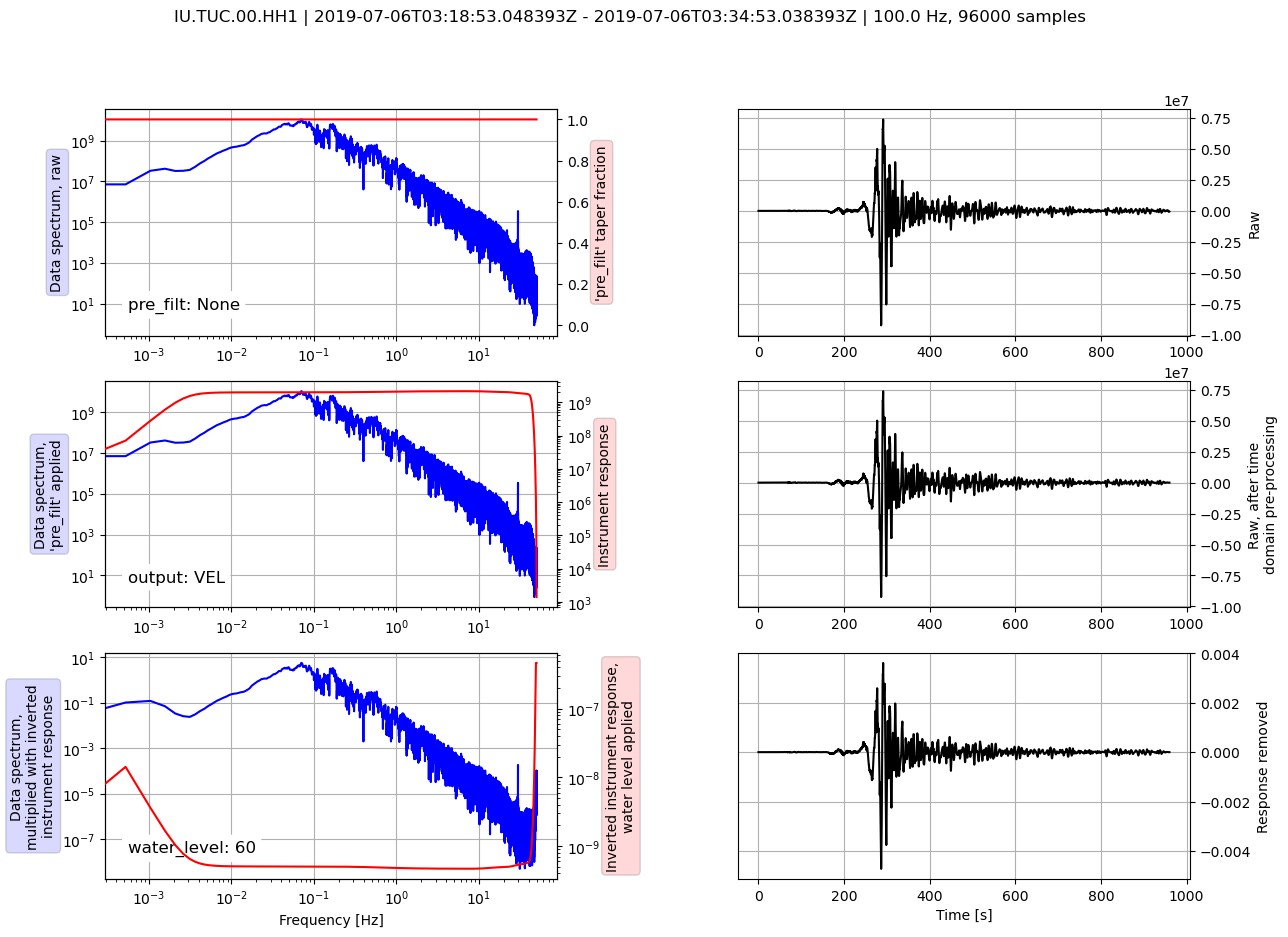

In [9]:
# Eliminar la respuesta instrumental
st_rem.remove_response(output='VEL', plot=True)

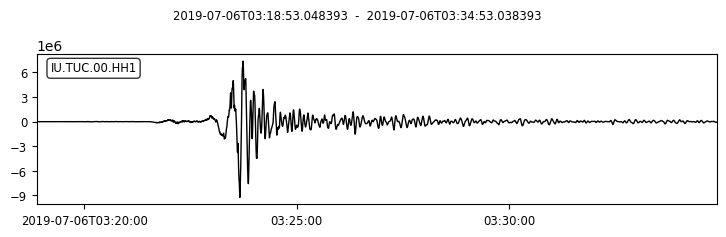

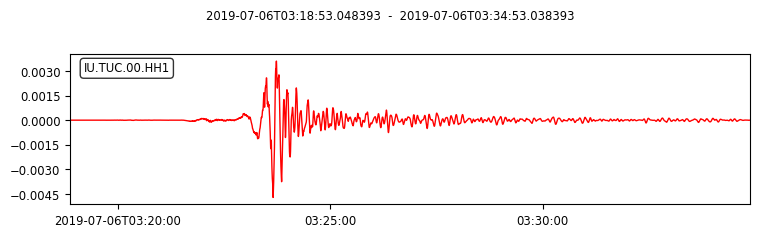

In [10]:
# Visualización de las formas de onda
st.plot();
st_rem.plot(color='red');

## 2. Lectura y Visualización de Metadatos de Estaciones <a id="2-visualizar-estaciones"></a>
Esta sección se basa en la segunda libreta que compartiste. 

Aquí leemos y visualizamos metadatos de estaciones sísmicas en formato StationXML.

In [16]:
from obspy import read_inventory
from obspy import read

In [13]:
# Lectura de un archivo StationXML
inventory = read_inventory("C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/metadatos/station_PFO.xml", format="STATIONXML")
print(type(inventory))

<class 'obspy.core.inventory.inventory.Inventory'>


In [14]:
# Exploración de la estructura del inventario
network = inventory[0]
station = network[0]
channel = station[0]
print(channel.response)

Channel Response
	From M/S (Velocity in Meters Per Second) to COUNTS (Digital Counts)
	Overall Sensitivity: 5.24814e+09 defined at 0.050 Hz
	4 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 3314.4
		Stage 2: PolesZerosResponseStage from V to V, gain: 1
		Stage 3: CoefficientsTypeResponseStage from V to COUNTS, gain: 1.58333e+06
		Stage 4: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1


In [18]:
# Lectura de formas de onda y eliminación de la respuesta instrumental
st = read("C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/metadatos/waveform_PFO.mseed")
inv = read_inventory("C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/metadatos/station_PFO.xml")

<Figure size 640x480 with 0 Axes>

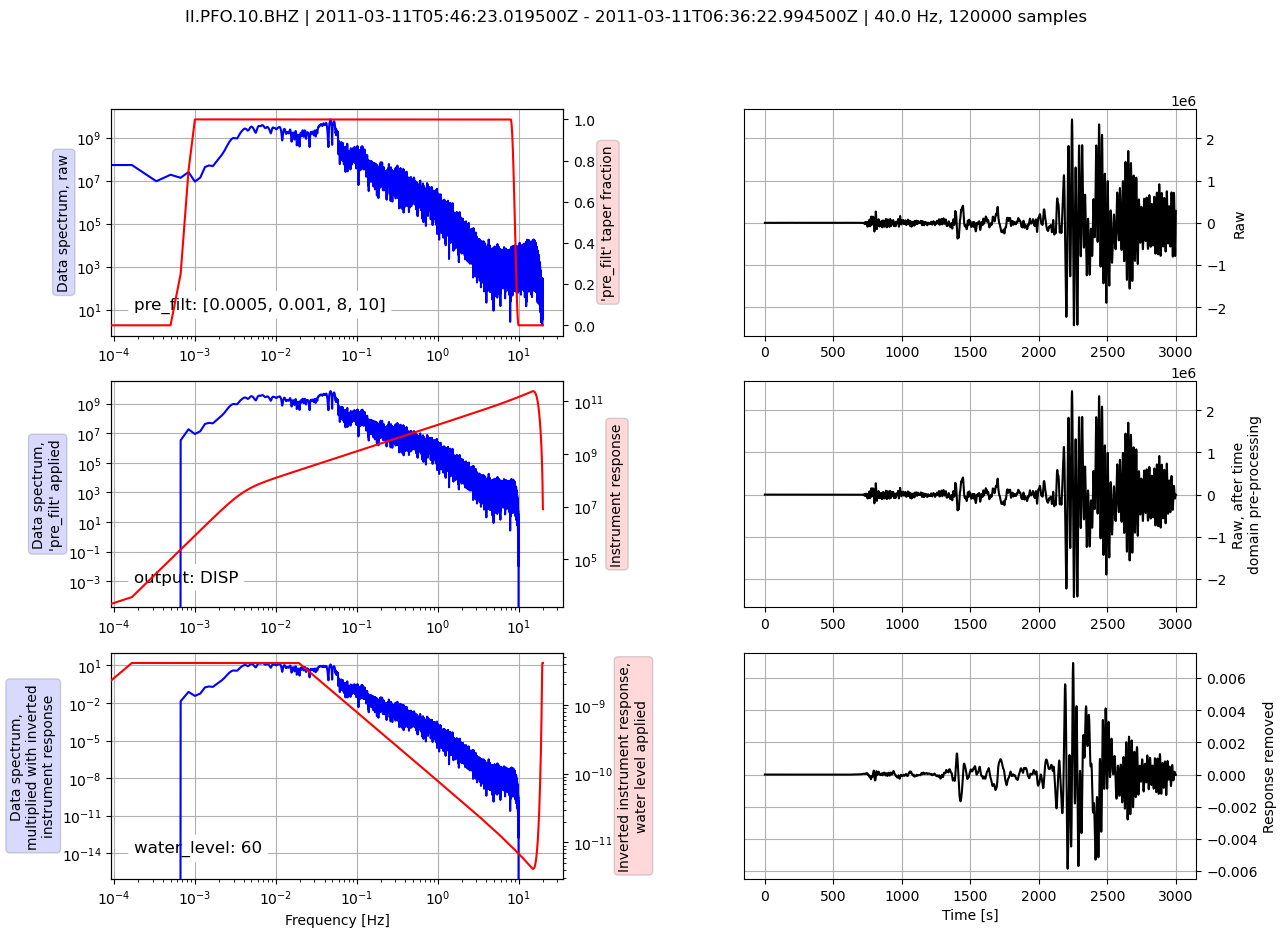

In [19]:
st.remove_response(inventory=inv, water_level=60, pre_filt=(0.0005, 0.001, 8, 10), output="DISP", plot=True);

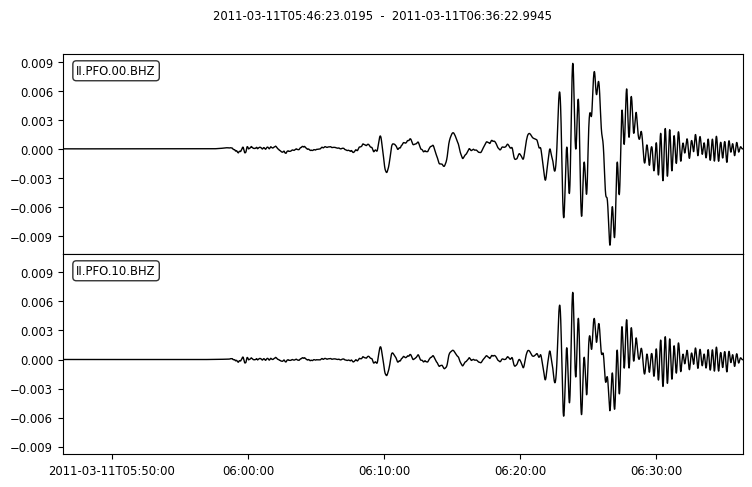

In [20]:
st.plot();

## 3. Lectura y Visualización de Metadatos de Eventos Sísmicos <a id="3-visualizar-eventos"></a>
Esta sección se basa en la tercera libreta que compartiste. 

Aquí leemos y visualizamos metadatos de eventos sísmicos en formato QuakeML.

In [21]:
from obspy import read_events

In [22]:
# Lectura de un archivo QuakeML
catalog = read_events("C:/Users/Huawei/Desktop/Apoyo_docencia/Sismologia/Archivos/metadatos/event_tohoku_with_big_aftershocks.xml")
print(catalog)

5 Event(s) in Catalog:
2011-03-11T05:46:23.200000Z | +38.296, +142.498 | 9.1  MW
2011-03-11T06:15:37.570000Z | +36.227, +141.088 | 7.9  MW
2011-03-11T06:25:50.740000Z | +38.051, +144.630 | 7.6  MW
2011-04-07T14:32:43.290000Z | +38.276, +141.588 | 7.1  MW
2011-07-10T00:57:10.800000Z | +38.034, +143.264 | 7.0  MW


In [23]:
# Exploración de la estructura del catálogo
event = catalog[0]
print(event.origins[0])
print(event.magnitudes[0])

Origin
	   resource_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?originid=9933375")
	          time: UTCDateTime(2011, 3, 11, 5, 46, 23, 200000)
	     longitude: 142.498
	      latitude: 38.2963
	         depth: 19700.0
	 creation_info: CreationInfo(author='ISC')
Magnitude
	    resource_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?magnitudeid=16642444")
	            mag: 9.1
	 magnitude_type: 'MW'
	      origin_id: ResourceIdentifier(id="smi:service.iris.edu/fdsnws/event/1/query?originid=9933383")
	  creation_info: CreationInfo(author='GCMT')


In [27]:
# Filtrado de eventos por magnitud
largest_magnitude_events = catalog.filter("magnitude >= 7.8")
print(largest_magnitude_events)

2 Event(s) in Catalog:
2011-03-11T05:46:23.200000Z | +38.296, +142.498 | 9.1  MW
2011-03-11T06:15:37.570000Z | +36.227, +141.088 | 7.9  MW


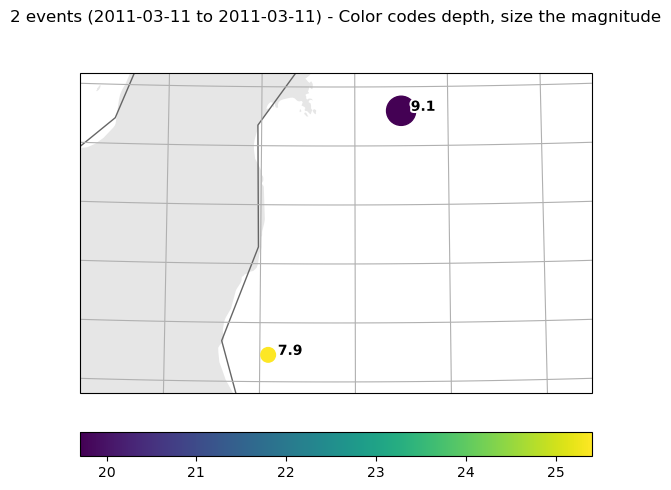

In [29]:
# Visualización del catálogo en un mapa
largest_magnitude_events.plot(projection="local");

## 4. Creación de un Catálogo de Eventos Personalizado <a id="4-catálogo"></a>
Esta sección también se basa en la tercera libreta. 

Aquí creamos un catálogo de eventos personalizado desde cero y lo guardamos en formato QuakeML.

In [31]:
from obspy import UTCDateTime
from obspy.core.event import Catalog, Event, Origin, Magnitude
from obspy.geodetics import FlinnEngdahl

In [35]:
cat = Catalog()
cat.description = "Just a fictitious toy example catalog built from scratch"

e = Event()
e.event_type = "not existing"

o = Origin()
o.time = UTCDateTime(2014, 2, 23, 18, 0, 0)
o.latitude = 47.6
o.longitude = 12.0
o.depth = 10000
o.depth_type = "operator assigned"
o.evaluation_mode = "manual"
o.evaluation_status = "preliminary"
o.region = FlinnEngdahl().get_region(o.longitude, o.latitude)

m = Magnitude()
m.mag = 7.2
m.magnitude_type = "Mw"

m2 = Magnitude()
m2.mag = 7.4
m2.magnitude_type = "Ms"

# also included could be: custom picks, amplitude measurements, station magnitudes,
# focal mechanisms, moment tensors, ...

# make associations, put everything together
cat.append(e)
e.origins = [o]
e.magnitudes = [m, m2]
m.origin_id = o.resource_id
m2.origin_id = o.resource_id

print(cat)
cat.write("my_custom_events.xml", format="QUAKEML")

1 Event(s) in Catalog:
2014-02-23T18:00:00.000000Z | +47.600,  +12.000 | 7.2  Mw | manual
